In [1]:
# import google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# replace <PATH-TO-YOUR-ZIP> with the path on your google drive
# Example: ! unzip /content/drive/MyDrive/M214A\ Winter\ 2026/Project/M214_project_data.zip -d /content/
! unzip /content/drive/MyDrive/M214_project_data.zip -d /content/

Archive:  /content/drive/MyDrive/M214_project_data.zip
   creating: /content/M214_project_data/
   creating: /content/M214_project_data/test_clean/
  inflating: /content/M214_project_data/test_clean/7_lucas_2.wav  
  inflating: /content/M214_project_data/test_clean/6_yweweler_2.wav  
  inflating: /content/M214_project_data/test_clean/4_jackson_1.wav  
  inflating: /content/M214_project_data/test_clean/1_nicolas_3.wav  
  inflating: /content/M214_project_data/test_clean/8_lucas_3.wav  
  inflating: /content/M214_project_data/test_clean/2_nicolas_2.wav  
  inflating: /content/M214_project_data/test_clean/4_george_0.wav  
  inflating: /content/M214_project_data/test_clean/4_yweweler_3.wav  
  inflating: /content/M214_project_data/test_clean/6_george_3.wav  
  inflating: /content/M214_project_data/test_clean/7_lucas_0.wav  
  inflating: /content/M214_project_data/test_clean/3_lucas_4.wav  
  inflating: /content/M214_project_data/test_clean/3_nicolas_4.wav  
  inflating: /content/M214_proje

In [3]:
import os
import random
import numpy as np
import copy

# Set before CUDA ops for deterministic CUDA kernels.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchaudio
import librosa
from glob import glob
import time

SEED = 0
#SEED = int(time.time())

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

In [4]:
# ============================================================
# Dataset paths
# ============================================================
root_folder = "/content"
TRAIN_DIR       = root_folder + "/M214_project_data/train_clean"
TEST_CLEAN_DIR    = root_folder + "/M214_project_data/test_clean"
TEST_NOISY_5DB_DIR    = root_folder + "/M214_project_data/test_snr_5db_babble"
TEST_NOISY_10DB_DIR   = root_folder + "/M214_project_data/test_snr_10db_babble"

# ============================================================
# Audio loading
# ============================================================

def load_audio(audio_file):
    audio, fs = torchaudio.load(audio_file)
    audio = audio.numpy().reshape(-1)
    return audio, int(fs)

In [5]:
import librosa
import numpy as np
import scipy.ndimage

#final crop spectral subtraction
def spec_sub_crop(audio, n_fft=512, hop_length=160, alpha=1.0, beta=0.05, noise_window_frames=15, delta_percentile=40):

    # STFT

    stft = librosa.stft(audio, n_fft=n_fft, hop_length=hop_length)
    magnitude, phase = librosa.magphase(stft)
    num_frames = magnitude.shape[1]

    if num_frames == 0:
        return audio, 0

    # VAD using rms

    rms = librosa.feature.rms(y=audio, frame_length=n_fft, hop_length=hop_length)[0]

    # Threshold based on percentile

    rms_threshold = np.percentile(rms, 20)
    rms_floored = np.maximum(rms, rms_threshold)
    rms_smoothed = scipy.ndimage.gaussian_filter1d(rms_floored, sigma=3)

    # calculate delta

    delta = librosa.feature.delta(rms_smoothed, width=5)
    abs_delta = np.abs(delta)

    # Get rid of edge effects

    pad_frames = 5 // 2
    abs_delta[:pad_frames] = 0
    abs_delta[-pad_frames:] = 0

    # Threshold deltas

    delta_thresh = np.percentile(abs_delta, delta_percentile)
    active_frames = np.where(abs_delta > delta_thresh)[0]

    # Cropping boundary

    start_frame = 0
    if len(active_frames) > 0:
        end_frame = active_frames[-1]
    else:
        end_frame = num_frames - 1

    if start_frame >= end_frame:
        end_frame = num_frames - 1

    # Noise Estimation

    noise_frames = np.arange(end_frame, num_frames)
    if len(noise_frames) < 3:
        noise_frames = np.arange(max(0, num_frames - noise_window_frames), num_frames)

    noise_profile = np.mean(magnitude[:, noise_frames], axis=1, keepdims=True)

    # Spectral Subtraction

    speech_magnitude = magnitude[:, start_frame:end_frame]
    speech_phase = phase[:, start_frame:end_frame]

    # Noise Profile & Spectral Floor

    subtracted = speech_magnitude - (alpha * noise_profile)
    clean_magnitude = np.maximum(subtracted, beta * noise_profile)

    reconstructed_stft = clean_magnitude * speech_phase
    clean_audio_cropped = librosa.istft(reconstructed_stft, hop_length=hop_length)

    return clean_audio_cropped

# Modified soft floor

def soft_floor(x, thresh, beta=2.0):
    return thresh + (1.0 / beta) * np.log1p(np.exp(beta * (x - thresh)))

# Rasta filter to condition for deltas calculation

def rasta_filter(signal):
    numer = np.array([0.2, 0.1, 0, -0.1, -0.2])
    denom = np.array([1, -0.98])
    zi = scipy.signal.lfilter_zi(numer, denom)
    filtered, _ = scipy.signal.lfilter(numer, denom, signal, zi=zi * signal[0])
    return filtered

# Delta function with adaptive width

def compute_delta(data, width=9, order=1):
    is_1d = data.ndim == 1
    if is_1d:
        data = np.atleast_2d(data)

    num_frames = data.shape[1]
    if num_frames < width:
        pad_amount = width - num_frames
        padded_data = np.pad(data, pad_width=((0, 0), (0, pad_amount)), mode='edge')
        delta = librosa.feature.delta(padded_data, width=width, order=order)
        out = delta[:, :num_frames]
    else:
        out = librosa.feature.delta(data, width=width, order=order)

    return out[0] if is_1d else out

def extract_feature(audio, fs):
    N_MFCC = 24
    WIN_LENGTH = 200
    HOP_LENGTH = 80
    N_FFT = 256

    # Pre-emphasis

    audio = librosa.effects.preemphasis(audio, coef=0.97)

    # Additive Noise Removal

    audio = spec_sub_crop(
        audio, n_fft=N_FFT, hop_length=HOP_LENGTH,
        alpha=1.0, beta=0.05
    )

    # Compute Base Mel-spectrogram & Log-Mel

    mels = librosa.feature.melspectrogram(
        y=audio, sr=fs, n_fft=N_FFT, hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH, n_mels=N_MFCC, fmin=128, fmax=4000
    )
    mels_db1 = librosa.power_to_db(mels, ref=np.max)

    # Calculate SVD

    U, S, Vh = np.linalg.svd(mels_db1, full_matrices=False)

    # Keep only the top 5

    k = min(5, mels_db1.shape[0], mels_db1.shape[1])

    # Zero out noise and reconstruct

    S_k = np.zeros_like(S)
    S_k[:k] = S[:k]
    mels_db_svd = U @ np.diag(S_k) @ Vh

    # soft floor

    dynRange = 20
    mels_db_max = np.max(mels_db_svd)
    mels_db = soft_floor(mels_db_svd, mels_db_max - dynRange, 0.5)

    # Unsharp Mask

    sigma = 0.6
    alpha_unsharp = 0.8
    blurred = scipy.ndimage.gaussian_filter(mels_db, sigma=sigma)
    mels_db_sharp = mels_db + alpha_unsharp * (mels_db - blurred)

    # mels

    d0_mean, d0_std = np.mean(mels_db_sharp), np.std(mels_db_sharp) + 1e-6
    mels_base = (mels_db_sharp - d0_mean) / d0_std

    # deltas

    mels_rasta = np.apply_along_axis(rasta_filter, 1, mels_db_sharp)

    mels_delta = compute_delta(mels_rasta, width=9, order=1)
    d_mean, d_std = np.mean(mels_delta), np.std(mels_delta) + 1e-6
    mels_delta = (mels_delta - d_mean) / d_std

    mels_delta2 = compute_delta(mels_rasta, width=9, order=2)
    d2_mean, d2_std = np.mean(mels_delta2), np.std(mels_delta2) + 1e-6
    mels_delta2 = (mels_delta2 - d2_mean) / d2_std

    # mean (energy) delta
    mean_energy = np.mean(mels_rasta, axis=0)
    mean_delta = compute_delta(mean_energy, width=9, order=1)

    r_mean, r_std = np.mean(mean_delta), np.std(mean_delta) + 1e-6
    mean_delta = (mean_delta - r_mean) / r_std

    # Final features
    features = np.vstack([mels_base, mels_delta, mels_delta2, mean_delta])

    return features.astype(np.float32)

def extract_feature_from_file(audio_file):
    audio, fs = load_audio(audio_file)
    return extract_feature(audio, fs)

In [6]:
# ============================================================
# Dataset & DataLoader
# ============================================================

class FeatureDataset(torch.utils.data.Dataset):
    def __init__(self, X_list, y):
        self.X = X_list          # list of (F, T) np arrays
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])  # (F, T)
        return x, int(self.y[idx]), x.shape[1]


def collate_pad(batch):
    xs, ys, lens = zip(*batch)
    B = len(xs)
    F = xs[0].shape[0]
    T_max = max(lens)
    xb = torch.zeros(B, 1, F, T_max, dtype=xs[0].dtype)
    for i, x in enumerate(xs):
        xb[i, 0, :, :x.shape[1]] = x
    return xb, torch.tensor(ys, dtype=torch.long), torch.tensor(lens, dtype=torch.long)

# ============================================================
# Data loading
# ============================================================

def get_label(file_name):
    base = os.path.splitext(os.path.basename(file_name))[0]
    return int(base.split("_")[0])


def load_dir(data_dir, desc="Loading"):
    files = sorted(glob(os.path.join(data_dir, "*.wav")))
    if not files:
        print(f"No wav files found in {data_dir}")
        return [], []
    feats, labels = [], []
    for wav in files:
        feats.append(extract_feature_from_file(wav))
        labels.append(get_label(wav))
    print(f"  {desc}: {len(feats)} files loaded")
    return feats, labels

In [7]:
# ============================================================
# LSTM model
# ============================================================

class SimpleLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True,
            dropout=0.2
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 10),
        )

    def forward(self, x, lengths):
        # x: (B,1,F,T) -> (B,T,F)
        x = x.squeeze(1).permute(0, 2, 1).contiguous()

        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)  # (B, T_max, 256)

        # ---- mean pooling over valid frames (ignore padding) ----
        B, T_max, D = out.shape
        device = out.device

        # mask: (B, T_max), True for valid timesteps
        mask = torch.arange(T_max, device=device).unsqueeze(0) < lengths.unsqueeze(1)

        # expand mask to (B, T_max, D) and zero-out padding
        mask_f = mask.unsqueeze(-1).float()
        out_sum = (out * mask_f).sum(dim=1)                       # (B, D)
        denom = mask_f.sum(dim=1).clamp(min=1.0)                  # (B, 1)
        mean = out_sum / denom                                    # (B, D)

        return self.classifier(mean)

In [8]:
# ============================================================
# Evaluation
# ============================================================

import matplotlib.pyplot as plt
from sklearn import metrics

@torch.no_grad()
def evaluate(model, loader, device, plot_cm=False, class_names=None, title=None, save_path=None):
    """
    Returns:
      acc (float) by default.
      If plot_cm=True, also returns (acc, cm).
    """
    model.eval()
    if loader is None:
        return (0.0, None) if plot_cm else 0.0

    all_preds = []
    all_labels = []

    correct, total = 0, 0
    for xb, yb, lengths in loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        logits = model(xb, lengths)
        preds = logits.argmax(dim=1)

        correct += (preds == yb).sum().item()
        total += yb.size(0)

        if plot_cm:
            all_preds.append(preds.detach().cpu().numpy())
            all_labels.append(yb.detach().cpu().numpy())

    acc = correct / total if total > 0 else 0.0

    if not plot_cm:
        return acc

    y_pred = np.concatenate(all_preds) if all_preds else np.array([], dtype=np.int64)
    y_true = np.concatenate(all_labels) if all_labels else np.array([], dtype=np.int64)

    cm = metrics.confusion_matrix(y_true, y_pred, labels=None)

    # Plot
    disp = metrics.ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names if class_names is not None else None
    )
    disp.plot(values_format="d")
    plt.title(title or "Confusion Matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()

    return acc, cm

In [9]:
# Training
BATCH_SIZE = 32
NUM_EPOCHS = 40
LR = 3e-4

In [10]:
# --- Load data ---
train_feat, train_label   = load_dir(TRAIN_DIR, desc="Train")
test_feat,  test_label    = load_dir(TEST_CLEAN_DIR, desc="Test clean")
noisy5_feat, noisy5_label = load_dir(TEST_NOISY_5DB_DIR, desc="Test noisy 5dB")
noisy10_feat, noisy10_label = load_dir(TEST_NOISY_10DB_DIR, desc="Test noisy 10dB")

feat_dim = train_feat[0].shape[0]
print(f"\nFeature dim: {feat_dim}")
print(f"Train: {len(train_feat)}  |  Test clean: {len(test_feat)}  "
      f"|  Test noisy 5dB: {len(noisy5_feat)}  |  Test noisy 10dB: {len(noisy10_feat)}")

for name, flist in [("Train", train_feat), ("Test clean", test_feat),
                    ("Noisy 5dB", noisy5_feat), ("Noisy 10dB", noisy10_feat)]:
    if flist:
        lengths = [f.shape[1] for f in flist]
        print(f"  {name:10s} frames: min={min(lengths)}, max={max(lengths)}, mean={np.mean(lengths):.1f}")

y_train   = np.array(train_label, dtype=np.int64)
y_test    = np.array(test_label,  dtype=np.int64)
y_noisy5  = np.array(noisy5_label, dtype=np.int64)
y_noisy10 = np.array(noisy10_label, dtype=np.int64)

# --- DataLoaders ---
loader_g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    FeatureDataset(train_feat, y_train),
    batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_pad, generator=loader_g,
)
test_loader = DataLoader(
    FeatureDataset(test_feat, y_test),
    batch_size=16, shuffle=False, collate_fn=collate_pad
)
noisy5_loader = None
if noisy5_feat:
    noisy5_loader = DataLoader(
        FeatureDataset(noisy5_feat, y_noisy5),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )
noisy10_loader = None
if noisy10_feat:
    noisy10_loader = DataLoader(
        FeatureDataset(noisy10_feat, y_noisy10),
        batch_size=16, shuffle=False, collate_fn=collate_pad,
    )



  Train: 2500 files loaded
  Test clean: 300 files loaded
  Test noisy 5dB: 300 files loaded
  Test noisy 10dB: 300 files loaded

Feature dim: 73
Train: 2500  |  Test clean: 300  |  Test noisy 5dB: 300  |  Test noisy 10dB: 300
  Train      frames: min=11, max=226, mean=33.9
  Test clean frames: min=12, max=112, mean=33.6
  Noisy 5dB  frames: min=12, max=108, mean=33.8
  Noisy 10dB frames: min=12, max=111, mean=33.6


In [11]:
# --- Training ---
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = SimpleLSTM(input_size=feat_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=LR)

best_clean, best_clean_ep = 0.0, -1
best_5db,  best_5db_ep  = 0.0, -1
best_10db, best_10db_ep = 0.0, -1

"""
Save the checkpoint with the best 10 dB accuracy.
You may instead choose to save the model with the best clean or 5 dB accuracy,
but keep in mind that your final score depends on strong performance on all of the test sets, especially the noisy test set.
"""
saved_checkpoint = None

from tqdm.notebook import tqdm

for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Training"):
    net.train()
    total_loss = 0.0
    for xb, yb, lengths in train_loader:
        xb, yb, lengths = xb.to(device), yb.to(device), lengths.to(device)
        optimizer.zero_grad()
        loss = criterion(net(xb, lengths), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    clean_acc = evaluate(net, test_loader, device)
    acc_5db  = evaluate(net, noisy5_loader, device)
    acc_10db = evaluate(net, noisy10_loader, device)

    print(f"Epoch {epoch:02d}  loss={avg_loss:.4f}  "
          f"clean={clean_acc:.4f}  5dB={acc_5db:.4f}  10dB={acc_10db:.4f}")

    if clean_acc > best_clean:
        best_clean, best_clean_ep = clean_acc, epoch
    if acc_5db > best_5db:
        best_5db, best_5db_ep = acc_5db, epoch
        saved_checkpoint = copy.deepcopy(net.state_dict())  # save the best checkpoint
    if acc_10db > best_10db:
        best_10db, best_10db_ep = acc_10db, epoch


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 01  loss=2.0584  clean=0.4867  5dB=0.4667  10dB=0.4900
Epoch 02  loss=1.2232  clean=0.8600  5dB=0.8300  10dB=0.8600
Epoch 03  loss=0.5910  clean=0.9300  5dB=0.8767  10dB=0.9200
Epoch 04  loss=0.3420  clean=0.9533  5dB=0.9433  10dB=0.9600
Epoch 05  loss=0.2161  clean=0.9633  5dB=0.9267  10dB=0.9500
Epoch 06  loss=0.1489  clean=0.9767  5dB=0.9333  10dB=0.9533
Epoch 07  loss=0.1269  clean=0.9633  5dB=0.9400  10dB=0.9567
Epoch 08  loss=0.0886  clean=0.9767  5dB=0.9400  10dB=0.9733
Epoch 09  loss=0.0670  clean=0.9800  5dB=0.9467  10dB=0.9733
Epoch 10  loss=0.0538  clean=0.9700  5dB=0.9567  10dB=0.9733
Epoch 11  loss=0.0503  clean=0.9867  5dB=0.9567  10dB=0.9767
Epoch 12  loss=0.0477  clean=0.9667  5dB=0.9433  10dB=0.9767
Epoch 13  loss=0.0347  clean=0.9800  5dB=0.9500  10dB=0.9733
Epoch 14  loss=0.0428  clean=0.9900  5dB=0.9600  10dB=0.9767
Epoch 15  loss=0.0356  clean=0.9867  5dB=0.9633  10dB=0.9767
Epoch 16  loss=0.0226  clean=0.9900  5dB=0.9567  10dB=0.9800
Epoch 17  loss=0.0253  c

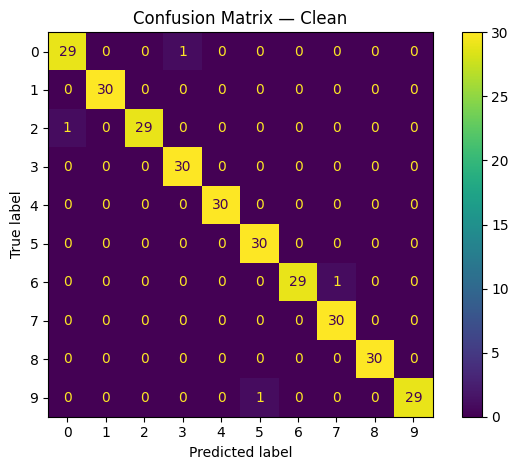

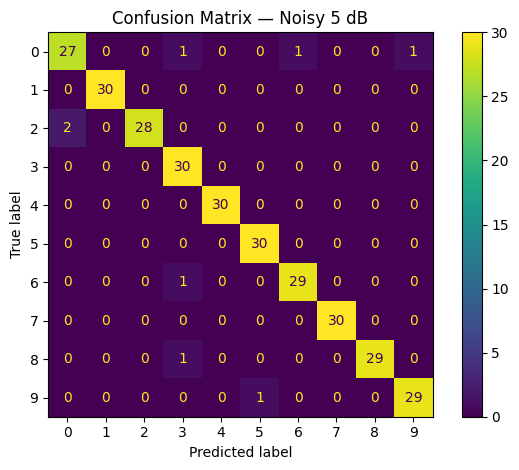

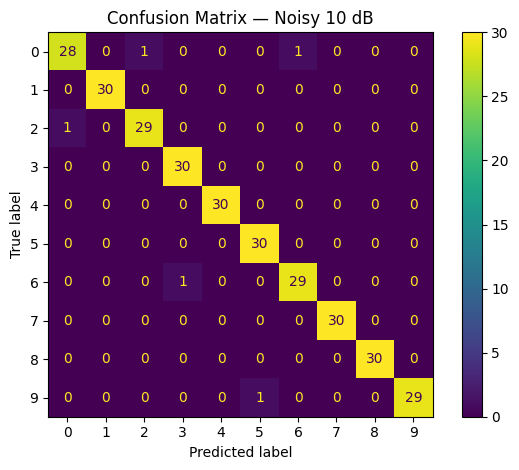


Best checkpoint loaded (epoch 22)
Clean accuracy : 0.9867
5dB accuracy   : 0.9733
10dB accuracy  : 0.9833


In [12]:
# load the best checkpoint before testing
net = SimpleLSTM(input_size=feat_dim).to(device)
net.load_state_dict(saved_checkpoint)
# clean_acc = evaluate(net, test_loader, device)
clean_acc, cm_clean = evaluate(
    net, test_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Clean"
)
acc_5db, cm_5db = evaluate(
    net, noisy5_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 5 dB"
)
acc_10db, cm_10db = evaluate(
    net, noisy10_loader, device,
    plot_cm=True,
    class_names=list(range(10)),
    title="Confusion Matrix — Noisy 10 dB"
)
print(f"\nBest checkpoint loaded (epoch {best_10db_ep})")
print(f"Clean accuracy : {clean_acc:.4f}")
print(f"5dB accuracy   : {acc_5db:.4f}")
print(f"10dB accuracy  : {acc_10db:.4f}")